In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../apps/api"))

import json
import logging
import boto3
import pandas as pd
import matplotlib.pyplot as plt

from livewell.backtest.loader import load_all_signals, load_price_history
from livewell.backtest.outcome import resolve_trade
from livewell.backtest.aggregator import build_summary

logging.basicConfig(level=logging.WARNING)

BUCKET = "livewell-data-prod"
ENV = "prod"

print("Setup complete.")

Setup complete.


In [2]:
signals = load_all_signals(env=ENV)
print(f"Loaded {len(signals)} signals with direction != 'none'")
instruments = list({s["s3_key"] for s in signals})
print(f"Instruments: {sorted(instruments)}")

Loaded 25 signals with direction != 'none'
Instruments: ['AUDUSD', 'EURGBP', 'EURUSD', 'GBPUSD', 'NKD', 'RTY', 'USDCAD', 'USDCHF', 'USDMXN', 'YM']


In [3]:
trades = []
skipped = 0

for s3_key in sorted(instruments):
    price_df = load_price_history(s3_key, BUCKET)
    if price_df.empty:
        print(f"WARNING: no price history for {s3_key}, skipping")
        continue
    instrument_signals = [s for s in signals if s["s3_key"] == s3_key]
    for signal in instrument_signals:
        result = resolve_trade(signal, price_df)
        if result is None:
            skipped += 1
        else:
            trades.append(result)

print(f"Resolved {len(trades)} trades, skipped {skipped}")

Resolved 16 trades, skipped 9


In [4]:
summary = build_summary(trades)
print(f"Total trades: {summary['totalTrades']}")
print(f"Win rate:     {summary['winRate']:.1%}")
print(f"Avg edge:     {summary['avgEdge']:.1%}")
print(f"Max drawdown: {summary['maxDrawdown']:.1%}")
print()
print("signal_valid split:")
split = summary["signalValidSplit"]
print(f"  Valid signals:   {split['valid']['trades']} trades, {split['valid']['winRate']:.1%} win rate")
print(f"  Invalid signals: {split['invalid']['trades']} trades, {split['invalid']['winRate']:.1%} win rate")

Total trades: 16
Win rate:     0.0%
Avg edge:     -100.0%
Max drawdown: -64.0%

signal_valid split:
  Valid signals:   2 trades, 0.0% win rate
  Invalid signals: 14 trades, 0.0% win rate


In [5]:
rows_df = pd.DataFrame(summary["rows"])
if not rows_df.empty:
    pivot = rows_df.groupby("market")[["winRate", "trades"]].apply(
        lambda g: pd.Series({
            "winRate": (g["winRate"] * g["trades"]).sum() / g["trades"].sum(),
            "trades": g["trades"].sum()
        })
    ).sort_values("winRate", ascending=False)
    print(pivot.to_string())

        winRate  trades
market                 
AUDUSD      0.0     2.0
EURGBP      0.0     2.0
GBPUSD      0.0     2.0
NKD         0.0     2.0
RTY         0.0     2.0
USDCAD      0.0     2.0
USDCHF      0.0     2.0
YM          0.0     2.0


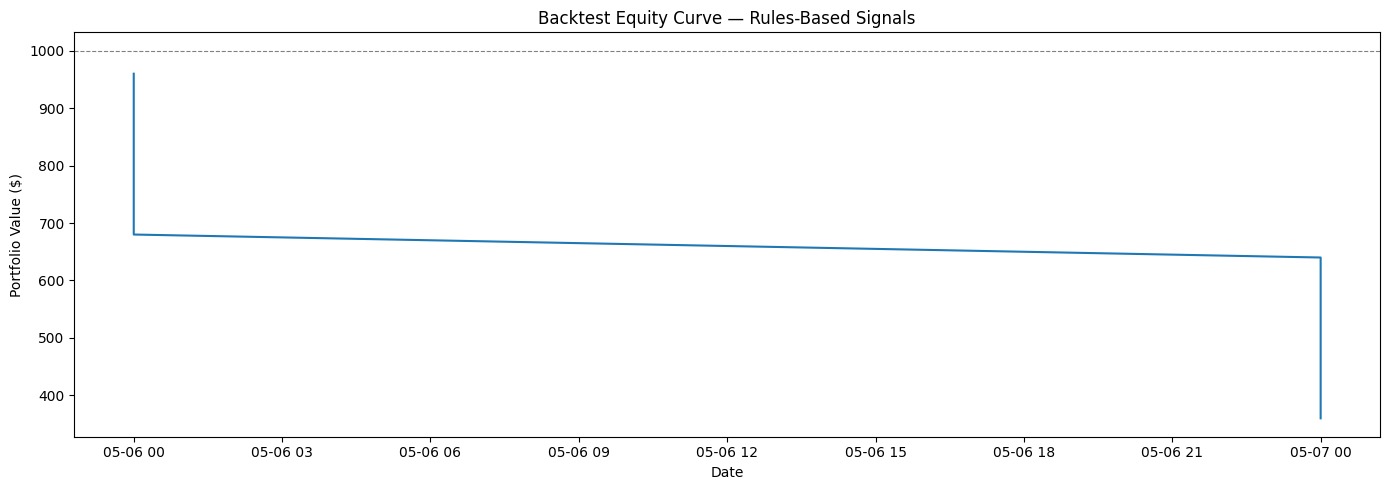

In [6]:
curve_df = pd.DataFrame(summary["equityCurve"])
if not curve_df.empty:
    curve_df["date"] = pd.to_datetime(curve_df["date"])
    plt.figure(figsize=(14, 5))
    plt.plot(curve_df["date"], curve_df["value"])
    plt.axhline(1000, color="gray", linestyle="--", linewidth=0.8)
    plt.title("Backtest Equity Curve — Rules-Based Signals")
    plt.xlabel("Date")
    plt.ylabel("Portfolio Value ($)")
    plt.tight_layout()
    plt.show()

In [7]:
# Trim equityCurve to monthly points to keep JSON small
curve_df = pd.DataFrame(summary["equityCurve"])
if not curve_df.empty:
    curve_df["date"] = pd.to_datetime(curve_df["date"])
    curve_df = curve_df.set_index("date").resample("ME").last().reset_index()
    curve_df["date"] = curve_df["date"].dt.strftime("%Y-%m-%d")
    summary["equityCurve"] = curve_df[["date", "value"]].to_dict(orient="records")

# Add expiryWindow field to rows (required by schema)
for row in summary["rows"]:
    row["expiryWindow"] = "Daily"

s3 = boto3.client("s3")
body = json.dumps(summary, default=str).encode()
s3.put_object(Bucket=BUCKET, Key="backtest/summary.json", Body=body, ContentType="application/json")
print(f"Written {len(body)} bytes to s3://{BUCKET}/backtest/summary.json")

Written 1300 bytes to s3://livewell-data-prod/backtest/summary.json


In [8]:
import urllib.request, urllib.error
API_URL = "https://3rxkdcbg4w2yshiyzoqsnd6c6q0cjjoo.lambda-url.us-west-1.on.aws"
try:
    with urllib.request.urlopen(f"{API_URL}/api/backtest/summary") as resp:
        data = json.loads(resp.read())
    print(f"API returned {data['totalTrades']} trades, win rate {data['winRate']:.1%}")
except urllib.error.HTTPError as e:
    print(f"HTTP {e.code} — has the backtest been written to S3 yet?")
except urllib.error.URLError as e:
    print(f"Cannot reach API: {e.reason}")

API returned 16 trades, win rate 0.0%
